In [4]:
import numpy as np
import pandas as pd

In [7]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense , Flatten , Conv2D , MaxPooling2D 

In [8]:
# generators

train_ds = keras.utils.image_dataset_from_directory(
    directory= r"C:\Users\itsam\Deep Learning\projects\train",
    labels='inferred' ,
    label_mode ='int',
    batch_size=32,
    image_size=(256,256)
    
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory= r"C:\Users\itsam\Deep Learning\projects\test",
    labels='inferred' ,
    label_mode ='int',
    batch_size=32,
    image_size=(256,256)
    
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [9]:
# normalise

def process(image , label):
    image = tf.cast(image/255. , tf.float32)
    return image , label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [10]:
  # now crearing the model

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3) , padding='valid' , activation ='relu' , input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2 , padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3) , padding='valid' , activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2 , padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3) , padding='valid' , activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2 , padding='valid'))



model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\itsam\anaconda3\envs\gpu_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      14,745,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam' , loss='binary_crossentropy' , metrics=['accuracy'])

In [13]:
history = model.fit(train_ds , epochs=10 , validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 460s 733ms/step - accuracy: 0.6487 - loss: 0.6207 - val_accuracy: 0.7376 - val_loss: 0.5112
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 442s 707ms/step - accuracy: 0.7765 - loss: 0.4633 - val_accuracy: 0.7846 - val_loss: 0.4622
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 439s 702ms/step - accuracy: 0.8367 - loss: 0.3611 - val_accuracy: 0.7982 - val_loss: 0.5176
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 434s 695ms/step - accuracy: 0.9008 - loss: 0.2369 - val_accuracy: 0.8080 - val_loss: 0.5323
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 828s 1s/step - accuracy: 0.9499 - loss: 0.1298 - val_accuracy: 0.7946 - val_loss: 0.7176
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 578s 924ms/step - accuracy: 0.9723 - loss: 0.0789 - val_accuracy: 0.7972 - val_loss: 0.8353
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 464s 740ms/step - accuracy: 0.9797 - loss: 0.0580 - val_accuracy: 0.8020 - val_loss: 0.9351
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 509s 813ms/step - accuracy: 0.9871 - lo

In [18]:
import matplotlib.pyplot as plt

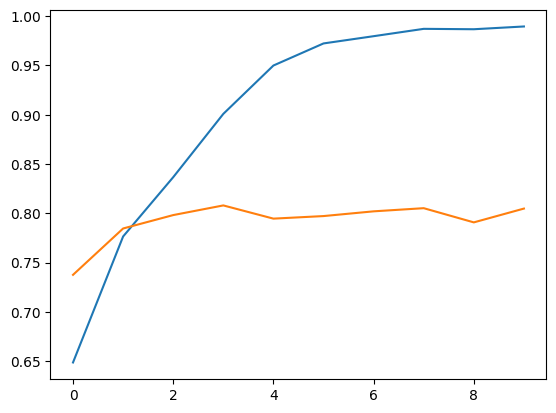

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

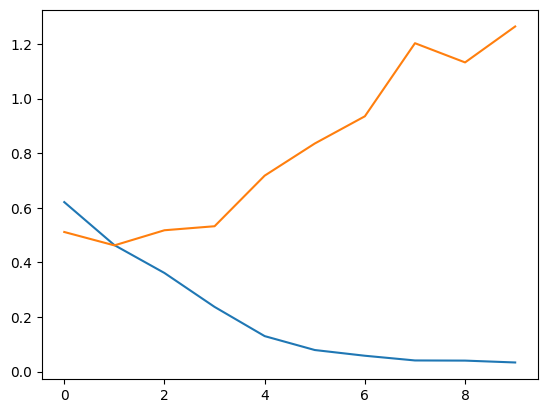

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])